## BPTT 

**BPTT（Backpropagation Through Time，通过时间的反向传播）** ，是专门为 RNN 设计的反向传播算法，它的核心思想是：

1. **展开 RNN** ：将 RNN 按时间步展开，形成一个深度网络
2. **应用反向传播** ：在展开的网络中应用反向传播算法，但不同时间步共享相同的权重参数



**BPTT与BP的区别** ：

1. **时间展开** ：BPTT将RNN展开成一个深度网络（深度等于时间步数），然后应用反向传播。因此，BPTT本质上是BP在时间展开网络上的应用。
2. **参数共享** ：在展开的网络中，不同时间步的相同层共享相同的参数，因此梯度需要累加所有时间步的贡献。
3. **长序列问题** ：当时间步很长时，展开的网络会非常深，导致梯度消失或爆炸问题（即长期依赖问题）。而标准BP通常用于固定层数的网络，层数不会随着数据变化。
4. **计算方式** ：BPTT需要保存每个时间步的中间状态（隐藏状态等），以便反向传播时使用，这可能导致较高的内存消耗。

## Truncated BPTT



**Truncated BPTT（通过时间的截断反向传播）** ，是一种用于训练循环神经网络（RNN）的技术。其核心思想是： **将长序列切分成较小的片段，在每个片段上独立执行BPTT，同时保留片段之间的隐状态传递，但是截断了梯度传播。**



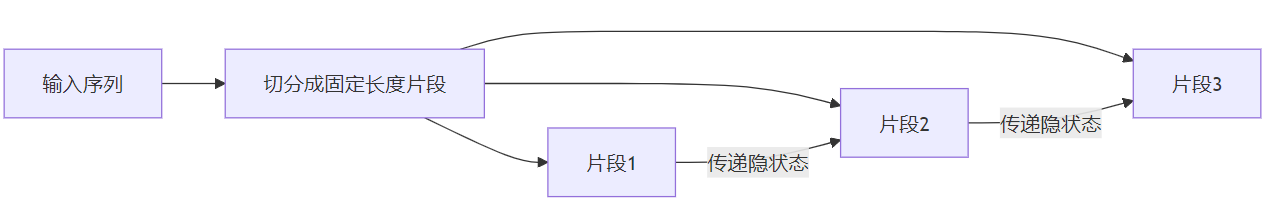

e.g.

**前向传播** ：

- 处理第1个片段（时间步1到k）：使用初始隐状态 $h_0$ ，其中 $$h_k = RNN(x_{1:k}, h_0)$$

- 处理第2个片段（时间步k+1到2k）：**复用** $h_k$ 作为初始状态，但 **不回溯梯度** ，其中 $$h_{2k} = RNN(x_{k+1:2k}, detach(h_k))$$

**反向传播** ：

- 在片段内部执行完整BPTT
- 梯度在片段边界被截断：片段2的梯度 **不会传播到片段1**